In [1]:
import requests

slug = "presidential-election-winner-2024"
url = f"https://gamma-api.polymarket.com/events?slug={slug}"
data = requests.get(url).json()

# Pak de markets (één per kandidaat)
for market in data[0]['markets']:
    print(market['conditionId'], market['question'])

0xdd22472e552920b8438158ea7238bfadfa4f736aa4cee91a6b86c39ead110917 Will Donald Trump win the 2024 US Presidential Election?
0x14018049e265a2d88f284be9588e2e3542e3a3df08ccdb344d28355dd7fdd8ef Will Joe Biden win the 2024 US Presidential Election?
0xced9f9d90c94db9f1e1dbd7d9fba82fe4fa7431c0d4e91e28896c8ac2d6acadd Will Nikki Haley win the 2024 US Presidential Election?
0x40bbdd26dc08406eedcb913efee7f7faddf50e16fc21caedb4972d57fd71e0d1 Will Gavin Newsom win the 2024 US Presidential Election?
0x7da35195ac3c7bf167f88ab0c27067a99020e36de67d39968b71d9debcdd925e Will Robert F. Kennedy Jr. win the 2024 US Presidential Election?
0xad6d309aaa500d96855996e84da00dfb2379548a693ca684d0877cf94fec05d1 Will Ron DeSantis win the 2024 US Presidential Election?
0x696baf880832d000a37ea87cc94235b1ac58e7e9fe7a144ccf5d141877629134 Will Vivek Ramaswamy win the 2024 US Presidential Election?
0xc6485bb7ea46d7bb89beb9c91e7572ecfc72a6273789496f78bc5e989e4d1638 Will Kamala Harris win the 2024 US Presidential Election?

In [6]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# ─── STAP 1: Haal token_id op via Gamma API (NIET conditionId!) ───
slug = "presidential-election-winner-2024"
gamma_url = f"https://gamma-api.polymarket.com/events?slug={slug}"
event = requests.get(gamma_url).json()[0]

# Bekijk alle kandidaten + hun token IDs
for market in event['markets']:
    tokens = market.get('clobTokenIds', '[]')
    print(f"{market['question'][:50]} → tokens: {tokens}")

Will Donald Trump win the 2024 US Presidential Ele → tokens: ["21742633143463906290569050155826241533067272736897614950488156847949938836455", "48331043336612883890938759509493159234755048973500640148014422747788308965732"]
Will Joe Biden win the 2024 US Presidential Electi → tokens: ["88027839609243624193415614179328679602612916497045596227438675518749602824929", "34731657770883441140875001518098751138877095477683682718012432921110142479972"]
Will Nikki Haley win the 2024 US Presidential Elec → tokens: ["19083349462791593334532840548890602187185739923311385087650426802477691161360", "25663677275476030658483179785762851061160843737234225579491314980654272946621"]
Will Gavin Newsom win the 2024 US Presidential Ele → tokens: ["99200347365169760700385453164878188504479548439905371494493482364634358863823", "88063614818983277039870506697948521713429593096456892435153186054911641634952"]
Will Robert F. Kennedy Jr. win the 2024 US Preside → tokens: ["75551890681049796405776295654438099776333

In [15]:
# ─── STAP 2: Kies het juiste token (Trump = Yes token) ───
import json

trump_market = next(
    m for m in event['markets'] 
    if 'Trump' in m['question']
)

# clobTokenIds heeft [yes_token_id, no_token_id]
token_ids = json.loads(trump_market['clobTokenIds'])
trump_yes_token = token_ids[0]
print(f"Trump YES token_id: {trump_yes_token}")

Trump YES token_id: 21742633143463906290569050155826241533067272736897614950488156847949938836455


In [16]:
# ─── STAP 3: Haal prijshistorie op (correct voor afgesloten markt) ───
url = "https://clob.polymarket.com/prices-history"

params = {
    "market": trump_yes_token,   # ← token_id, NIET conditionId
    "interval": "max",           # ← verplicht voor afgesloten markten
    "fidelity": 1440,            # ← in minuten: 1440 = dagelijks, 720 = 12u
}

resp = requests.get(url, params=params).json()

# Veilig checken wat de API teruggeeft
print(resp.keys())               # debug: wat zit erin?
history = resp.get('history', resp)  # soms zit data direct in root

dict_keys(['history'])


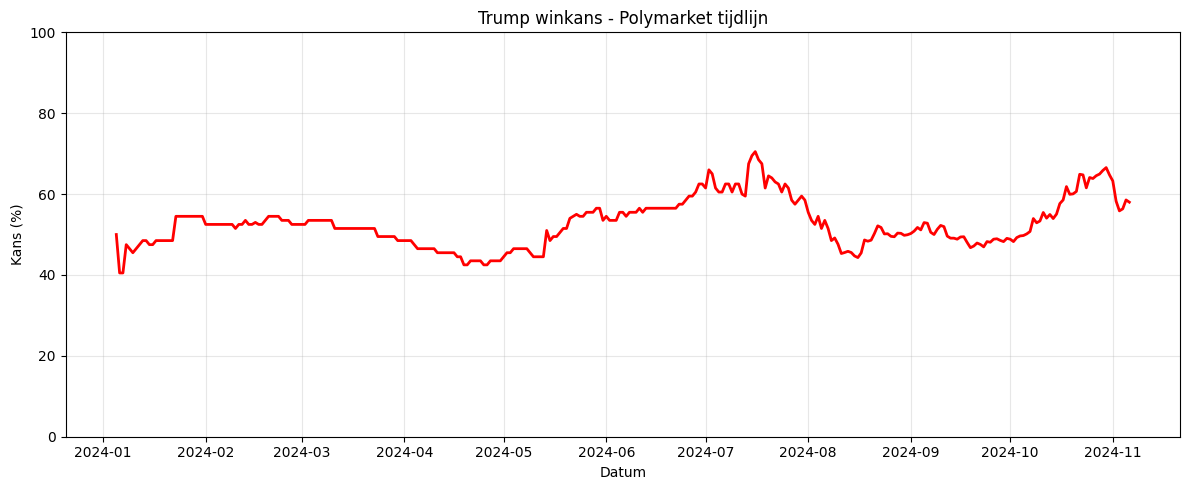

In [17]:
# ─── STAP 4: Visualiseer ───
df = pd.DataFrame(history)
df['date'] = pd.to_datetime(df['t'], unit='s')
df['price'] = df['p'].astype(float)

plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['price'] * 100, color='red', linewidth=2)
plt.title("Trump winkans - Polymarket tijdlijn")
plt.ylabel("Kans (%)")
plt.xlabel("Datum")
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
df

,t,p,date,price
0,1704412803,0.5000,2024-01-05 00:00:03,0.5000
1,1704499202,0.4050,2024-01-06 00:00:02,0.4050
2,1704585602,0.4050,2024-01-07 00:00:02,0.4050
3,1704672002,0.4750,2024-01-08 00:00:02,0.4750
4,1704758403,0.4650,2024-01-09 00:00:03,0.4650
...,...,...,...,...
302,1730505603,0.5825,2024-11-02 00:00:03,0.5825
303,1730592003,0.5585,2024-11-03 00:00:03,0.5585
304,1730678403,0.5635,2024-11-04 00:00:03,0.5635
305,1730764802,0.5855,2024-11-05 00:00:02,0.5855


Trump token:  21742633143463906290569050155826241533067272736897614950488156847949938836455
Harris token: 69236923620077691027083946871148646972011131466059644796654161903044970987404


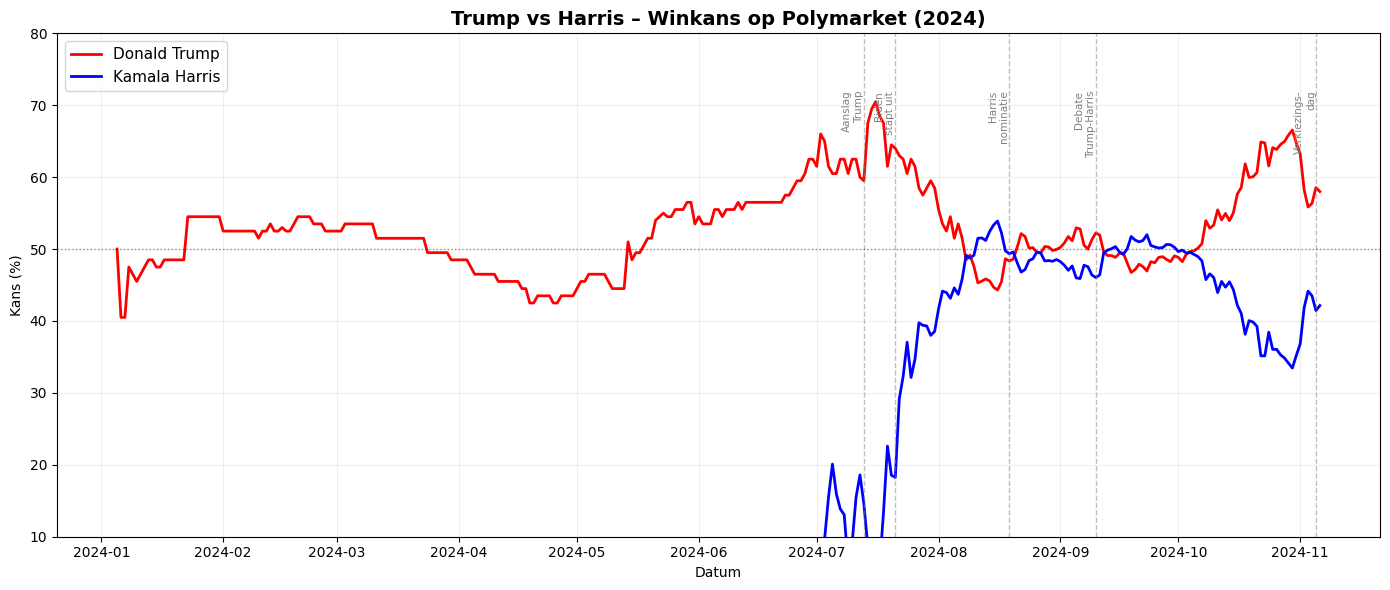

In [27]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt

# ─── STAP 1: Haal event data op ───
slug = "presidential-election-winner-2024"
gamma_url = f"https://gamma-api.polymarket.com/events?slug={slug}"
event = requests.get(gamma_url).json()[0]

# ─── STAP 2: Haal token IDs op voor Trump én Harris ───
def get_yes_token(markets, name):
    market = next(m for m in markets if name in m['question'])
    token_ids = json.loads(market['clobTokenIds'])
    return token_ids[0]  # index 0 = Yes token

trump_token = get_yes_token(event['markets'], 'Trump')
harris_token = get_yes_token(event['markets'], 'Harris')

print(f"Trump token:  {trump_token}")
print(f"Harris token: {harris_token}")

# ─── STAP 3: Haal prijshistorie op ───
def get_price_history(token_id, label):
    url = "https://clob.polymarket.com/prices-history"
    params = {
        "market": token_id,
        "interval": "max",
        "fidelity": 1440,  # dagelijks
    }
    resp = requests.get(url, params=params).json()
    history = resp.get('history', [])
    
    df = pd.DataFrame(history)
    df['date'] = pd.to_datetime(df['t'], unit='s')
    df['price'] = df['p'].astype(float) * 100  # naar percentage
    df['candidate'] = label
    
    # Deduplicate: max per dag (filtert Yes/No dubbelingen)
    df['date_only'] = df['date'].dt.date
    df = df.groupby('date_only')['price'].max().reset_index()
    df.columns = ['date', 'price']
    df['candidate'] = label
    return df

trump_df  = get_price_history(trump_token,  'Donald Trump')
harris_df = get_price_history(harris_token, 'Kamala Harris')

# ─── STAP 4: Visualiseer ───
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(trump_df['date'],  trump_df['price'],  color='red',  linewidth=2, label='Donald Trump')
ax.plot(harris_df['date'], harris_df['price'], color='blue', linewidth=2, label='Kamala Harris')

# Key events
key_events = {
    '2024-07-13': 'Aanslag\nTrump',
    '2024-07-21': 'Biden\nstapt uit',
    '2024-08-19': 'Harris\nnominatie',
    '2024-09-10': 'Debate\nTrump-Harris',
    '2024-11-05': 'Verkiezings-\ndag',
}

for date_str, label in key_events.items():
    ax.axvline(pd.Timestamp(date_str), color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(pd.Timestamp(date_str), 72, label, rotation=90,
            fontsize=7.5, va='top', ha='right', color='gray')

ax.axhline(50, color='black', linestyle=':', alpha=0.4, linewidth=1)
ax.set_title("Trump vs Harris – Winkans op Polymarket (2024)", fontsize=14, fontweight='bold')
ax.set_ylabel("Kans (%)")
ax.set_xlabel("Datum")
ax.set_ylim(10, 80)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [33]:
# ─── Combineer Trump en Harris in één DataFrame ───

def get_price_history_full(token_id, label):
    url = "https://clob.polymarket.com/prices-history"
    params = {
        "market": token_id,
        "interval": "max",
        "fidelity": 720,
    }
    resp = requests.get(url, params=params).json()
    history = resp.get('history', [])
    
    df = pd.DataFrame(history)
    df['date'] = pd.to_datetime(df['t'], unit='s')
    df['probability'] = df['p'].astype(float) * 100
    df = df[['date', 'probability']].rename(columns={'probability': label})
    return df

trump_df  = get_price_history_full(trump_token,  'Trump (%)')
harris_df = get_price_history_full(harris_token, 'Harris (%)')

# Merge op datum (outer join om geen data te verliezen)
combined_df = pd.merge(trump_df, harris_df, on='date', how='outer')
combined_df = combined_df.sort_values('date').reset_index(drop=True)

# Rond af op 2 decimalen
combined_df['Trump (%)']  = combined_df['Trump (%)'].round(2)
combined_df['Harris (%)'] = combined_df['Harris (%)'].round(2)

print(combined_df)
print(f"\nShape: {combined_df.shape}")


                   date  Trump (%)  Harris (%)
0   2024-01-05 00:00:03      50.00         NaN
1   2024-01-05 12:00:03      40.50        3.45
2   2024-01-06 00:00:02      40.50        3.15
3   2024-01-06 12:00:02      40.50        2.70
4   2024-01-07 00:00:02      40.50        2.70
..                  ...        ...         ...
609 2024-11-04 12:00:03      57.05       43.00
610 2024-11-05 00:00:02      58.55       41.45
611 2024-11-05 12:00:02      62.25       37.85
612 2024-11-06 00:00:02      58.00       42.15
613 2024-11-06 12:00:03      99.85        0.05

[614 rows x 3 columns]

Shape: (614, 3)


In [37]:
final_dependent = combined_df[combined_df['date'] >= '2024-07-01']

In [39]:
final_dependent.dtypes

date          datetime64[ns]
Trump (%)            float64
Harris (%)           float64
dtype: object